
  [Реальный геном]
  N динуклеотидов = 99,999
  χ² = 1054.40   df = 9   p-value = 3.20e-221
  → Отвергаем H₀

  [Случайная]
  N динуклеотидов = 99,999
  χ² = 8.69   df = 9   p-value = 4.66e-01
  → Не отвергаем H₀


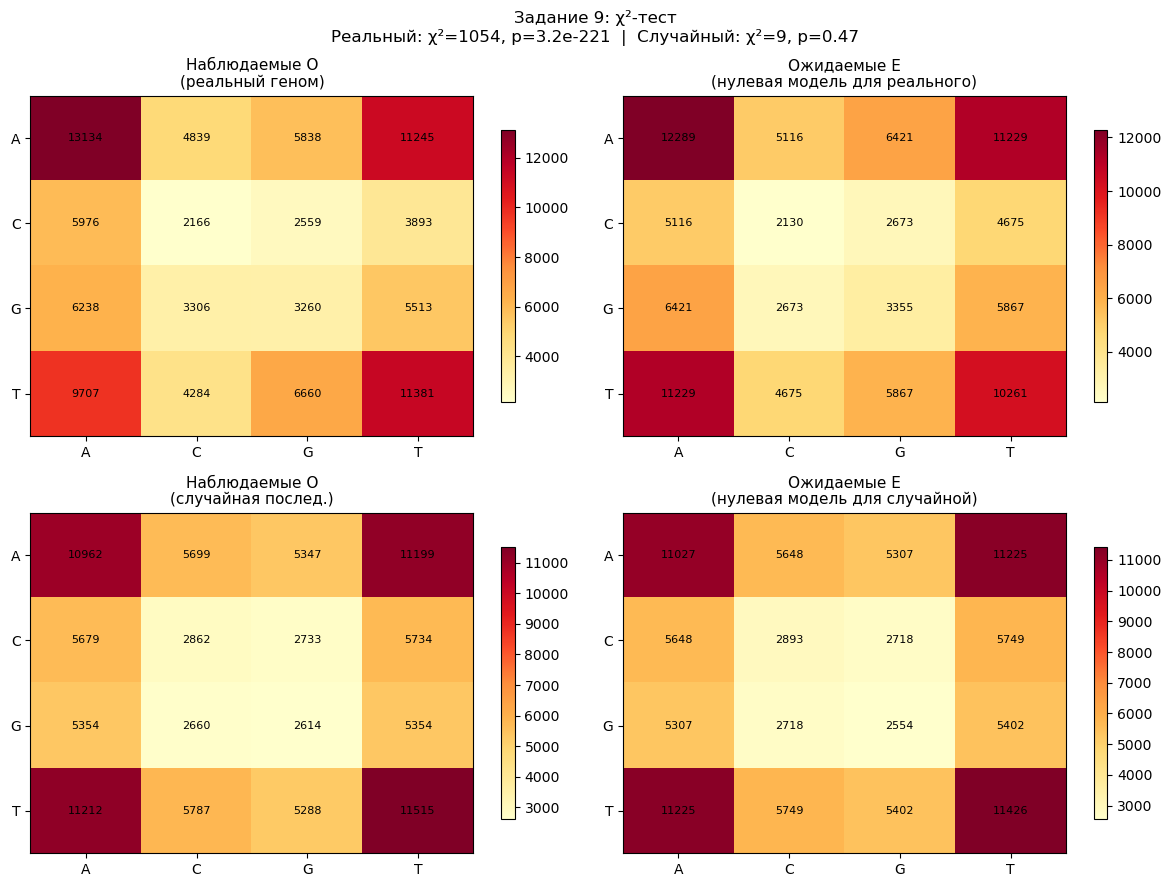

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline
 
NUCLEOTIDES = ["A", "C", "G", "T"]
NUC2IDX     = {n: i for i, n in enumerate(NUCLEOTIDES)}
FASTA_PATH  = "436.fasta.fa"
seq_parts = []
with open(FASTA_PATH) as f:
    for line in f:
        line = line.strip()
        if not line.startswith(">"):
            seq_parts.append(line.upper())
seq = "".join(seq_parts)
dinuc = np.zeros((4,4), dtype=int)
for k in range(len(seq)-1):
    a, b = seq[k], seq[k+1]
    if a in NUC2IDX and b in NUC2IDX:
        dinuc[NUC2IDX[a], NUC2IDX[b]] += 1
P = dinuc / dinuc.sum(axis=1, keepdims=True)
evals, evecs = np.linalg.eig(P.T)
idx = np.argmin(np.abs(evals - 1.0))
pi  = evecs[:, idx].real; pi /= pi.sum()

from scipy import stats as sp_stats
 
def chi2_test(sequence, label):
    n   = len(sequence)
    O   = np.zeros((4,4), dtype=float)
    for k in range(n-1):
        a, b = sequence[k], sequence[k+1]
        if a in NUC2IDX and b in NUC2IDX:
            O[NUC2IDX[a], NUC2IDX[b]] += 1
    freq = np.array([sequence[:n-1].count(ni) / (n-1) for ni in NUCLEOTIDES])
    N_pairs = O.sum()
    E = N_pairs * np.outer(freq, freq)
    chi2  = float(np.sum((O - E)**2 / np.where(E > 0, E, 1)))
    df    = 9
    pval  = sp_stats.chi2.sf(chi2, df)
 
    print(f"\n  [{label}]")
    print(f"  N динуклеотидов = {int(N_pairs):,}")
    print(f"  χ² = {chi2:.2f}   df = {df}   p-value = {pval:.2e}")
    print(f"  → {'Отвергаем H₀' if pval < 0.05 else 'Не отвергаем H₀'}")
    return O, E, chi2, pval
 
O_real, E_real, chi2_real, pval_real = chi2_test(seq[:100_000], "Реальный геном")
 
obs_freq_arr = np.array([seq.count(n)/len(seq) for n in NUCLEOTIDES])
rng2   = np.random.default_rng(seed=0)
random_seq = "".join(rng2.choice(list(NUCLEOTIDES), size=100_000, p=obs_freq_arr))
O_rand, E_rand, chi2_rand, pval_rand = chi2_test(random_seq, "Случайная")
 
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
data_list = [(O_real,  "Наблюдаемые O\n(реальный геном)"),
             (E_real,  "Ожидаемые E\n(нулевая модель для реального)"),
             (O_rand,  "Наблюдаемые O\n(случайная послед.)"),
             (E_rand,  "Ожидаемые E\n(нулевая модель для случайной)")]
 
for ax, (mat, title) in zip(axes.flat, data_list):
    im = ax.imshow(mat, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(4)); ax.set_xticklabels(NUCLEOTIDES)
    ax.set_yticks(range(4)); ax.set_yticklabels(NUCLEOTIDES)
    ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax, shrink=0.8)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{mat[i,j]:.0f}", ha="center", va="center", fontsize=8)
 
fig.suptitle(
    f"Задание 9: χ²-тест\n"
    f"Реальный: χ²={chi2_real:.0f}, p={pval_real:.1e}  |  "
    f"Случайный: χ²={chi2_rand:.0f}, p={pval_rand:.2f}",
    fontsize=12)
plt.tight_layout()
plt.show()

'''
Реальный геном: χ² = 1054, p = 3.2×10⁻²²¹ — гипотеза независимости нуклеотидов уверенно отвергается, 
соседние нуклеотиды статистически зависимы, модель 1-го порядка необходима. Случайная последовательность: 
χ² = 8.69, p = 0.47 — независимость не отвергается, что ожидаемо для нулевой модели.
'''